In [55]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
titanic = sns.load_dataset('titanic')

In [56]:

print(titanic.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


In [57]:
titanic['age'] = titanic['age'].fillna(titanic['age'].mean())
titanic = titanic.drop(columns=['class', 'deck', 'alive', 'embark_town', 'who'])
print(titanic.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   sex         891 non-null    object 
 3   age         891 non-null    float64
 4   sibsp       891 non-null    int64  
 5   parch       891 non-null    int64  
 6   fare        891 non-null    float64
 7   embarked    889 non-null    object 
 8   adult_male  891 non-null    bool   
 9   alone       891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(2)
memory usage: 57.6+ KB
None


<Axes: xlabel='pclass', ylabel='age'>

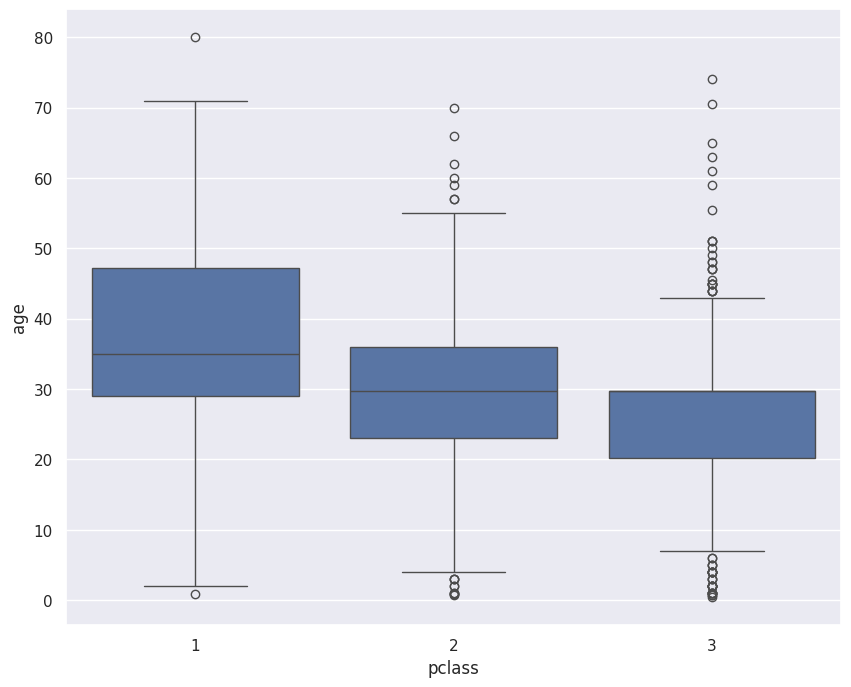

In [58]:
sns.boxplot(x=titanic['pclass'], y=titanic['age'])


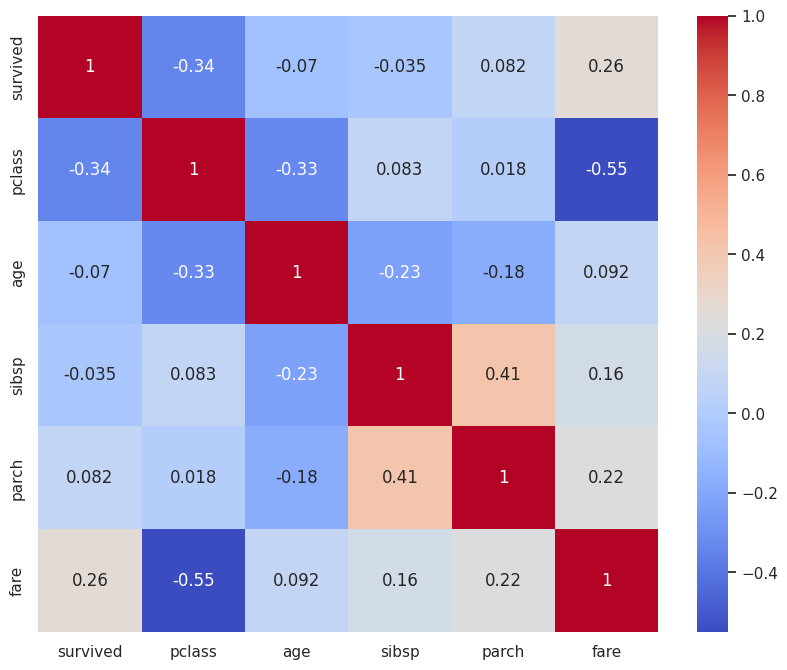

In [59]:
numeric_titanic = titanic.select_dtypes(include= ['number'])
sns.set(rc={'figure.figsize': (10,8)})
sns.heatmap(numeric_titanic.corr(), annot=True, cmap='coolwarm')
plt.show()

In [60]:
titanic["embarked"] = titanic["embarked"].fillna(titanic["embarked"].mode()[0])


In [61]:
titanic

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,alone
0,0,3,male,22.000000,1,0,7.2500,S,True,False
1,1,1,female,38.000000,1,0,71.2833,C,False,False
2,1,3,female,26.000000,0,0,7.9250,S,False,True
3,1,1,female,35.000000,1,0,53.1000,S,False,False
4,0,3,male,35.000000,0,0,8.0500,S,True,True
...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,True,True
887,1,1,female,19.000000,0,0,30.0000,S,False,True
888,0,3,female,29.699118,1,2,23.4500,S,False,False
889,1,1,male,26.000000,0,0,30.0000,C,True,True


In [62]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   sex         891 non-null    object 
 3   age         891 non-null    float64
 4   sibsp       891 non-null    int64  
 5   parch       891 non-null    int64  
 6   fare        891 non-null    float64
 7   embarked    891 non-null    object 
 8   adult_male  891 non-null    bool   
 9   alone       891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(2)
memory usage: 57.6+ KB


In [63]:
titanic['sex'] = titanic['sex'].map({'male' : 0, 'female' : 1 })
titanic = pd.get_dummies(titanic, columns=['embarked'])
print(titanic)

     survived  pclass  sex        age  sibsp  parch     fare  adult_male  \
0           0       3    0  22.000000      1      0   7.2500        True   
1           1       1    1  38.000000      1      0  71.2833       False   
2           1       3    1  26.000000      0      0   7.9250       False   
3           1       1    1  35.000000      1      0  53.1000       False   
4           0       3    0  35.000000      0      0   8.0500        True   
..        ...     ...  ...        ...    ...    ...      ...         ...   
886         0       2    0  27.000000      0      0  13.0000        True   
887         1       1    1  19.000000      0      0  30.0000       False   
888         0       3    1  29.699118      1      2  23.4500       False   
889         1       1    0  26.000000      0      0  30.0000        True   
890         0       3    0  32.000000      0      0   7.7500        True   

     alone  embarked_C  embarked_Q  embarked_S  
0    False       False       False    

In [64]:
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1
titanic['age_group'] = pd.cut(titanic['age'] , bins= [0,12,19,59,100], labels=['Child', 'Teenager', 'Adult', 'old'])
print(titanic.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    int64   
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   adult_male   891 non-null    bool    
 8   alone        891 non-null    bool    
 9   embarked_C   891 non-null    bool    
 10  embarked_Q   891 non-null    bool    
 11  embarked_S   891 non-null    bool    
 12  family_size  891 non-null    int64   
 13  age_group    891 non-null    category
dtypes: bool(5), category(1), float64(2), int64(6)
memory usage: 61.2 KB
None


In [65]:
from sklearn.preprocessing import MinMaxScaler , StandardScaler
print(titanic[['fare' , 'age']].head())
mn_scaler  = MinMaxScaler()
s_scaler = StandardScaler()
mn_titanic = titanic.copy()
mn_titanic[['fare', 'age']] = mn_scaler.fit_transform(titanic[['fare', 'age']])
print(mn_titanic[['fare' , 'age']])

      fare   age
0   7.2500  22.0
1  71.2833  38.0
2   7.9250  26.0
3  53.1000  35.0
4   8.0500  35.0
         fare       age
0    0.014151  0.271174
1    0.139136  0.472229
2    0.015469  0.321438
3    0.103644  0.434531
4    0.015713  0.434531
..        ...       ...
886  0.025374  0.334004
887  0.058556  0.233476
888  0.045771  0.367921
889  0.058556  0.321438
890  0.015127  0.396833

[891 rows x 2 columns]


In [66]:
s_titanic = titanic.copy()
s_titanic[['fare', 'age']] = s_scaler.fit_transform(s_titanic[['fare', 'age']])
print(s_titanic[['fare', 'age']])

         fare       age
0   -0.502445 -0.592481
1    0.786845  0.638789
2   -0.488854 -0.284663
3    0.420730  0.407926
4   -0.486337  0.407926
..        ...       ...
886 -0.386671 -0.207709
887 -0.044381 -0.823344
888 -0.176263  0.000000
889 -0.044381 -0.284663
890 -0.492378  0.177063

[891 rows x 2 columns]


In [67]:
titanic.to_csv('titanic_ready_for_modeling.csv', index=False)